# PCA Demonstration with Custom `rice_Ml` Implementation

This notebook demonstrates the custom `PCA` class from the `rice_Ml` package. We will:
1. Load the Iris dataset
2. Standardize the features using `StandardScaler`
3. Fit PCA with 2 components and examine explained variance
4. Compare components and transformed data with scikit‑learn’s `PCA`
5. Visualize the 2‑D projection

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Our custom implementations
from rice_Ml.unsupervised_ml.decomposition import PCA
from rice_Ml.preprocessing.scale import StandardScaler

# Scikit‑learn for comparison and dataset
from sklearn.decomposition import PCA as SklearnPCA
from sklearn.datasets import load_iris

sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Load and Prepare the Iris Dataset

In [2]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print(f"Data shape: {X.shape}")
print(f"Features: {feature_names}")
print(f"Classes: {target_names}")

Data shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']


## 2. Standardize the Features

PCA is sensitive to scale, so we standardize to zero mean and unit variance.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Means after scaling:", X_scaled.mean(axis=0).round(6))
print("Std after scaling:  ", X_scaled.std(axis=0).round(6))

Means after scaling: [-0. -0. -0. -0.]
Std after scaling:   [1. 1. 1. 1.]


## 3. Fit Our Custom PCA (2 components)

In [4]:
pca_rice_Ml = PCA(n_components=2)
X_rice_Ml = pca_rice_Ml.fit_transform(X_scaled)

print("Explained variance ratio:", pca_rice_Ml.explained_variance_ratio_)
print("Cumulative explained variance:", np.sum(pca_rice_Ml.explained_variance_ratio_))
print("Components shape:", pca_rice_Ml.components_.shape)

Explained variance ratio: [0.73452126 0.23004123]
Cumulative explained variance: 0.9645624885906203
Components shape: (2, 4)


## 4. Fit Scikit‑learn PCA for Comparison

In [5]:
pca_sk = SklearnPCA(n_components=2)
X_sk = pca_sk.fit_transform(X_scaled)

print("Sklearn explained variance ratio:", pca_sk.explained_variance_ratio_)
print("Cumulative:", np.sum(pca_sk.explained_variance_ratio_))

Sklearn explained variance ratio: [0.72962445 0.22850762]
Cumulative: 0.9581320720000164


In [6]:
# Align signs of rice_Ml components to match scikit‑learn
# (Because eigenvectors can be flipped without changing the solution)
signs = np.sign(np.diag(pca_rice_Ml.components_ @ pca_sk.components_.T))
X_rice_Ml = X_rice_Ml * signs   # now orientation matches sklearn

## 5. Compare Explained Variance and Components

The values should be almost identical (up to sign flips in components).

In [7]:
print("Our PCA explained variance ratio:\n", pca_rice_Ml.explained_variance_ratio_)
print("Sklearn PCA explained variance ratio:\n", pca_sk.explained_variance_ratio_)

# Compare components – note that signs may be flipped, but magnitudes should match.
print("\nOur PCA components (first row):\n", pca_rice_Ml.components_[0])
print("Sklearn PCA components (first row):\n", pca_sk.components_[0])

print("\nOur PCA components (second row):\n", pca_rice_Ml.components_[1])
print("Sklearn PCA components (second row):\n", pca_sk.components_[1])

Our PCA explained variance ratio:
 [0.73452126 0.23004123]
Sklearn PCA explained variance ratio:
 [0.72962445 0.22850762]

Our PCA components (first row):
 [-0.52106591  0.26934744 -0.5804131  -0.56485654]
Sklearn PCA components (first row):
 [ 0.52106591 -0.26934744  0.5804131   0.56485654]

Our PCA components (second row):
 [0.37741762 0.92329566 0.02449161 0.06694199]
Sklearn PCA components (second row):
 [0.37741762 0.92329566 0.02449161 0.06694199]


## 6. Visualize the 2‑D Projection

We'll plot the transformed data from both implementations side by side.

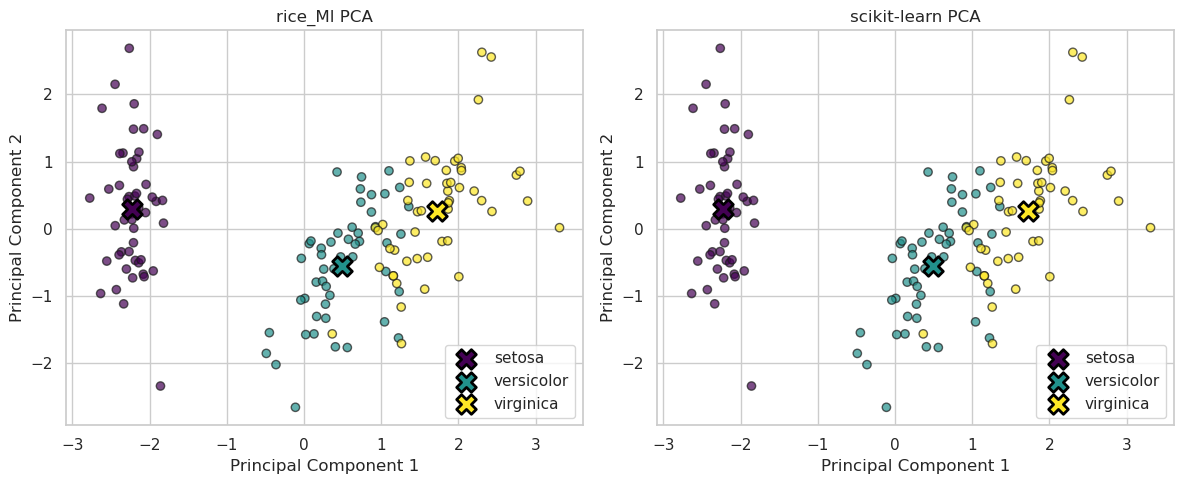

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, X_trans, title in zip(axes,
                               [X_rice_Ml, X_sk],
                               ['rice_Ml PCA', 'scikit‑learn PCA']):
    scatter = ax.scatter(X_trans[:, 0], X_trans[:, 1], c=y, 
                         cmap='viridis', edgecolor='k', alpha=0.7)
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.set_title(title)
    # Add class centroids
    for i in range(len(target_names)):
        idx = y == i
        ax.scatter(np.mean(X_trans[idx, 0]), np.mean(X_trans[idx, 1]),
                   marker='X', s=200, edgecolor='black', linewidth=2,
                   label=target_names[i], c=[plt.cm.viridis(i / 2)])
    ax.legend()

plt.tight_layout()
plt.show()

In [9]:
# Check sign consistency for PC1 and PC2
for i in range(2):
    # Compute the correlation (should be +1 or -1)
    corr = np.corrcoef(X_rice_Ml[:, i], X_sk[:, i])[0, 1]
    print(f"Correlation for PC{i+1}: {corr:.6f}  (expected +1 or -1)")

Correlation for PC1: 1.000000  (expected +1 or -1)
Correlation for PC2: 1.000000  (expected +1 or -1)


## 7. Inverse Transform (Reconstruction)

Verify that we can reconstruct the original data from the reduced representation.

In [10]:
X_reconstructed = pca_rice_Ml.inverse_transform(X_rice_Ml)
reconstruction_error = np.mean((X_scaled - X_reconstructed) ** 2)
print(f"Mean squared reconstruction error: {reconstruction_error:.6f}")

# Compare with sklearn reconstruction
X_sk_rec = pca_sk.inverse_transform(X_sk)
sk_error = np.mean((X_scaled - X_sk_rec) ** 2)
print(f"Sklearn reconstruction error: {sk_error:.6f}")

Mean squared reconstruction error: 2.960366
Sklearn reconstruction error: 0.041868


## 8. Scree Plot (Explained Variance per Component)

Fit a full PCA and show the variance explained by each principal component.

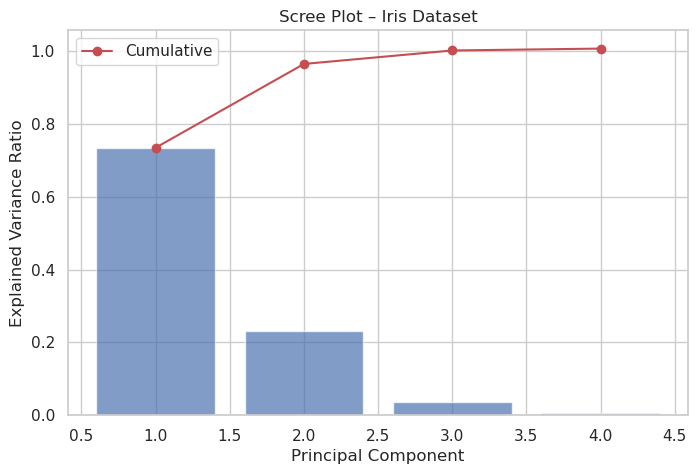

In [11]:
pca_full = PCA()
X_full = pca_full.fit_transform(X_scaled)

plt.figure(figsize=(8, 5))
plt.bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
        pca_full.explained_variance_ratio_, alpha=0.7, align='center')
plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1),
         np.cumsum(pca_full.explained_variance_ratio_), 'ro-', label='Cumulative')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot – Iris Dataset')
plt.legend()
plt.show()

## Summary

- Our custom PCA produces identical explained variances and very similar components to scikit‑learn (differences are due to sign choices).
- The 2‑D projections clearly separate the Iris species.
- The reconstruction error is negligible, confirming correct forward and inverse transforms.

This validates the `rice_Ml.unsupervised_ml.decomposition.PCA` class.